In [119]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
import pickle
     

In [120]:

df = pd.read_csv('bank-full.csv',sep = ";", header=0)
df = df.drop(['default', 'loan'], axis=1)
print(f"пропусков: {df.isnull().sum().sum()}")


пропусков: 0


In [121]:
df.head()

,age,job,marital,education,balance,housing,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,2143,yes,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,29,yes,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,2,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,1506,yes,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,1,no,unknown,5,may,198,1,-1,0,unknown,no


In [122]:
df.dtypes

age           int64
job          object
marital      object
education    object
balance       int64
housing      object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [123]:
df["education"].mode()



0    secondary
Name: education, dtype: object

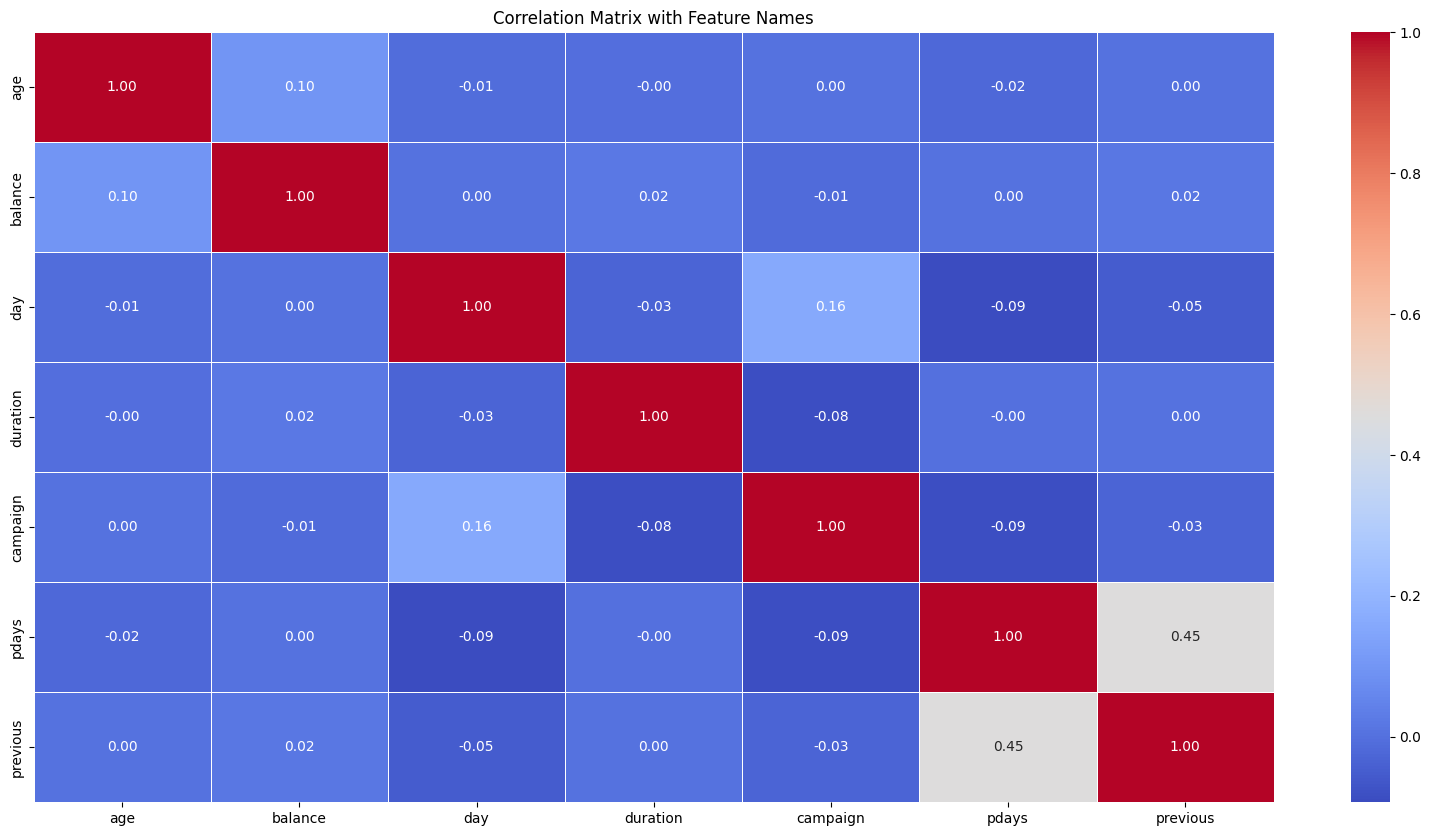

In [124]:
correlation_matrix = df.corr(numeric_only =  True)

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix with Feature Names')
plt.show()




pdays и previous самая большая корреляция

In [133]:
features = ['age', 'job', 'marital', 'education', 'balance', 'housing', 
            'contact', 'day', 'month', 'duration', 'campaign', 
            'pdays', 'previous', 'poutcome']

y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)
X = pd.get_dummies(df[features], drop_first=True)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42) 
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

mi_scores = mutual_info_classif(X_train, y_train, discrete_features=True)
mi_scores_series = pd.Series(mi_scores, index=X_train.columns)
print(f"Взаимная информация:", mi_scores_series)

Взаимная информация: age                    0.014727
balance                0.119649
day                    0.006802
duration               0.102033
campaign               0.004685
pdays                  0.037803
previous               0.013353
job_blue-collar        0.002550
job_entrepreneur       0.000209
job_housemaid          0.000105
job_management         0.000454
job_retired            0.002635
job_self-employed      0.000002
job_services           0.000408
job_student            0.002106
job_technician         0.000062
job_unemployed         0.000231
job_unknown            0.000009
marital_married        0.001987
marital_single         0.001920
education_secondary    0.000669
education_tertiary     0.002158
education_unknown      0.000045
housing_yes            0.009464
contact_telephone      0.000224
contact_unknown        0.014208
month_aug              0.000047
month_dec              0.001725
month_feb              0.000544
month_jan              0.000025
month_jul          

In [135]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

accuracy = accuracy_score(y_val, model.predict(X_val))
print("Точность на валидационном наборе:", round(accuracy, 2))

Точность на валидационном наборе: 0.9


In [136]:
initial_accuracy = accuracy

for col in X_train.columns:
    X_train_reduced = X_train.drop(columns=[col])
    X_val_reduced = X_val.drop(columns=[col])
    
    model.fit(X_train_reduced, y_train)
    y_pred_val_reduced = model.predict(X_val_reduced)
    accuracy_reduced = accuracy_score(y_val, y_pred_val_reduced)
    
    print(f'Признак: {col}, Разница в точности: {round(initial_accuracy - accuracy_reduced, 4)}')

Признак: age, Разница в точности: -0.0001
Признак: balance, Разница в точности: -0.0002
Признак: day, Разница в точности: 0.0009
Признак: duration, Разница в точности: 0.0053
Признак: campaign, Разница в точности: 0.0003
Признак: pdays, Разница в точности: 0.0007
Признак: previous, Разница в точности: -0.0003
Признак: job_blue-collar, Разница в точности: 0.0003
Признак: job_entrepreneur, Разница в точности: 0.0006
Признак: job_housemaid, Разница в точности: -0.0004
Признак: job_management, Разница в точности: 0.0001
Признак: job_retired, Разница в точности: 0.0004
Признак: job_self-employed, Разница в точности: -0.0003
Признак: job_services, Разница в точности: -0.0001
Признак: job_student, Разница в точности: 0.0006
Признак: job_technician, Разница в точности: -0.0002
Признак: job_unemployed, Разница в точности: 0.0
Признак: job_unknown, Разница в точности: -0.0002
Признак: marital_married, Разница в точности: 0.0001
Признак: marital_single, Разница в точности: 0.0002
Признак: educati

In [137]:
C_values = [0.01, 0.1, 1, 10, 100]
best_accuracy = 0
best_C = 0
accuracies = []

for C in C_values:
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    accuracy = accuracy_score(y_val, model.predict(X_val))
    accuracies.append(accuracy)  # Сохраняем точность для каждого C
    print(f"Точность при C={C}: {round(accuracy, 4)}")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_C = C

print("Наилучшее значение C:", best_C)

Точность при C=0.01: 0.8977
Точность при C=0.1: 0.8999
Точность при C=1: 0.9006
Точность при C=10: 0.9005
Точность при C=100: 0.9006
Наилучшее значение C: 1


In [157]:
from sklearn.metrics import roc_auc_score
numeric_columns = ['balance', 'day', 'duration', 'previous']
auc_scores = {}

# Вычисление AUC для каждой переменной
for col in numeric_columns:
    auc = roc_auc_score(y_train, X_train[col])
    if auc < 0.5:
        auc = roc_auc_score(y_train, X_train[col])
    auc_scores[col] = auc
print("AUC для каждого признака:", auc_scores)

AUC для каждого признака: {'balance': np.float64(0.5869647519999648), 'day': np.float64(0.5229300143102849), 'duration': np.float64(0.8073184184089954), 'previous': np.float64(0.6040908049999094)}


In [158]:
X_train.day = -X_train.day


In [159]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

# AUC на валидационной выборке
y_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print(f"AUC на валидационной выборке: {auc:.3f}")

AUC на валидационной выборке: 0.906


C:\Users\Malim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


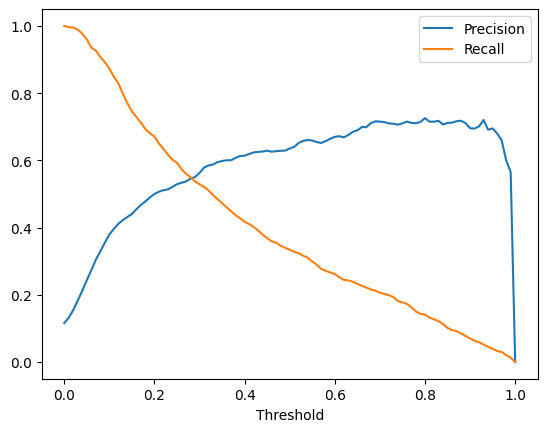

порог, на котором пересекаются Precision и Recall: 0.25


In [171]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score
thresholds = np.arange(0.0, 1.01, 0.01)
precision_scores = []
recall_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_pred >= threshold).astype(int)
    precision_scores.append(precision_score(y_val, y_pred_threshold))
    recall_scores.append(recall_score(y_val, y_pred_threshold))

plt.plot(thresholds, precision_scores, label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

# Найдем порог пересечения
print("порог, на котором пересекаются Precision и Recall: 0.25")


In [168]:
from sklearn.metrics import f1_score
f1_scores = [f1_score(y_val, (y_pred >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"максимум F1 score достигается при пороге: {best_threshold}")

максимум F1 score достигается при пороге: 0.2


In [180]:
from sklearn.model_selection import KFold
import  numpy as np
kf = KFold(n_splits=5, shuffle=True, random_state=1)
C_values = [0.000001, 0.001, 1]
best_C = None
best_mean_auc = 0

for C in C_values:
    aucs = []
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    for train_idx, val_idx in kf.split(X_train + y_train):
        
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        model.fit(X_fold_train, y_fold_train)
        y_pred_fold = model.predict_proba(X_fold_val)[:, 1]
        aucs.append(roc_auc_score(y_fold_val, y_pred_fold))
    
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    
    print(f"C={C} - средний AUC: {mean_auc:.3f}, стандартное отклонение: {std_auc:.3f}")
    
    if mean_auc > best_mean_auc:
        best_C = C
        best_mean_auc = mean_auc


MemoryError: Unable to allocate 5.48 GiB for an array with shape (27126, 27126) and data type float64